# Time Series Analysis: Representation

In [130]:
# packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import meteostat as ms
from datetime import datetime

Let's load a classic periodic time series example showing trend and seasonality: The Airline Passenger Dataset recording passengers per day. We can observe how the overall passenger count as well as the amplitude size increase over time.

In [131]:
bolzano = ms.Point(46.5, 11.35, 262)  

# Get nearby weather stations
stations = ms.stations.nearby(bolzano, limit=1, radius=10000)
station_ids = stations.index.tolist()

start = datetime(2023, 6, 1)
end = datetime(2023, 6, 15)

ms.config.block_large_requests = False
data = ms.hourly(station=station_ids, start=start, end=end, parameters=["temp"])

ts_data = data.fetch().reset_index().pivot(index='time', columns='station', values='temp').squeeze()

count     337.0
mean     20.731
std       4.551
min        12.0
25%        17.0
50%        20.0
75%        24.3
max        30.0
Name: 16020, dtype: Float64


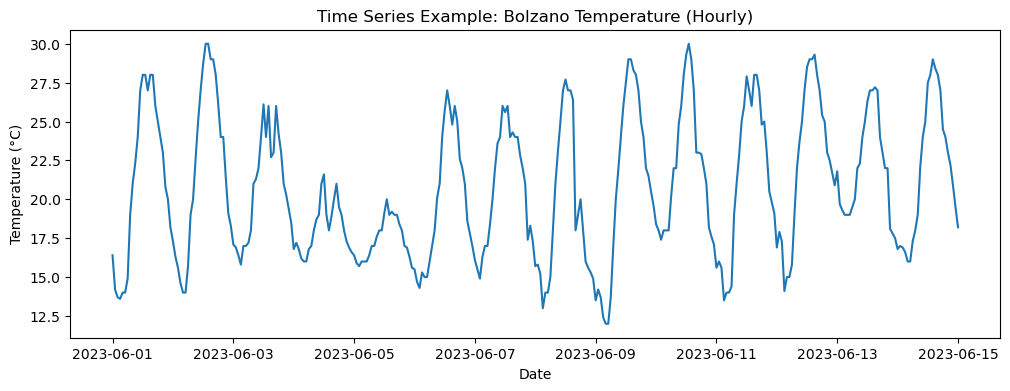

In [132]:
# some statistics of the original time series
print(ts_data.describe().round(3))

# plot of the time series
plt.figure(figsize=(12, 4))
plt.plot(ts_data.index, ts_data.values)
plt.title("Time Series Example: Bolzano Temperature (Hourly)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

## 1. Normalization
As time series can have a difference in values due to the underlying scale or other reasons, normalizing them for comparison can be useful. Two of the most used normalization techniques are min-max and z-normalization. 

Min-Max-Normalization uses the min and max values of the time series to fit it into the range of [0,1] with the min always being mapped to 0 and the max to 1. In comparison to z-normalization, mean and standard deviation are not standardised.

In [133]:
def min_max_norm(time_series):
    ts_min = np.min(time_series)
    ts_max = np.max(time_series)
    
    return (time_series - ts_min) / (ts_max - ts_min)

# other options: sklearn.preprocessing.normalize, sklearn.preprocessing.MinMaxScaler
ts_min_max = min_max_norm(ts_data.values)

print(pd.DataFrame(ts_min_max).describe().round(3))

           0
count  337.0
mean   0.485
std    0.253
min      0.0
25%    0.278
50%    0.444
75%    0.683
max      1.0


Z-Normalization shifts the time series in a way that makes it have a mean of 0 and a standard deviation of 1. 

When the function is supposed to accept any time series, it is important to handle constant series. They have a standard deviation of 0, which would break the division. One can either check for a constant series in the beginning or add a very small number to the denominator which does not influence regular values too much but division safe.

In [134]:
def znorm(time_series):
    ts_mean = np.mean(time_series)
    ts_std = np.std(time_series)

    return (time_series - ts_mean) / (ts_std + 1e-8)

# other options: sklearn.preprocessing.normalize, sklearn.preprocessing.StandardScaler
ts_znormed = znorm(ts_data.values)

print(pd.DataFrame(ts_znormed).describe().round(2))

           0
count  337.0
mean    -0.0
std      1.0
min    -1.92
25%    -0.82
50%    -0.16
75%     0.79
max     2.04


Lets compare the two normalizations: Notice, how z-normalization doesn't bound the values per se. Furthermore, we can still observe the bijective property of both normalizations, e.g. how peaks and valleys align.

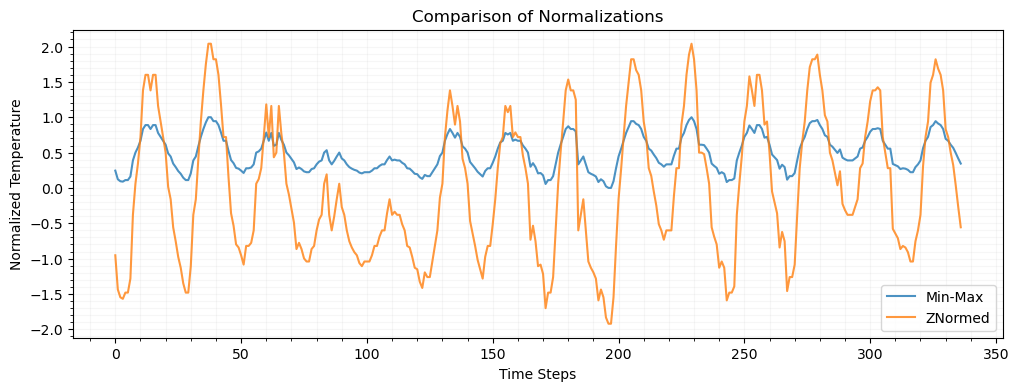

In [172]:
plt.figure(figsize=(12, 4))
plt.plot(ts_min_max, label='Min-Max', alpha=0.8)
plt.plot(ts_znormed, label='ZNormed', alpha=0.8)

plt.title("Comparison of Normalizations")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Temperature")
plt.legend()

plt.minorticks_on()
plt.grid(which="both", alpha=0.1)
plt.show()

## 2. Representation

As time series can grow up to extreme size, representation techniques are getting more and more important. They can allow the time series to be stored more memory efficient (dimensionality reduction) or support different analysation techniques through their structure.

**Important side note: In the following dimensionality reductions, we often keep the removed dimensions as zeros for ease of use. This of course does not reduce the memory size - one had to manage an extra index structure to correctly restore the time series from the remaining dimensions**

From the several shown representation techniques in the lecture, we will implement the following three:
1. DFT (Discrete Fourier Transformation)
2. PAA (Piecewise Aggregate Approximation)
3. SAX (Symbolic Aggregate Approximation)

Additionally, we will extend the lecture sections about wavelets.

### 2.1. DFT

!!TODO: intuitive, correct explanation of DFT!!

Discrete Fourier Transformation is a way to represent a discrete set of points as a sum of trigonometric, i.e. sinus and cosinus functions. The formula for DFT is 

$$ X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-i2\pi \frac{k}{N}n}$$

where 
- $X_k$ is a complex number that tells us the amplitude and phase of the k'th frequency
- $\sum_{n=0}^{N-1} x_n$ says that we are aggregating information from all our data points
- $e^{-i2\pi}$ describes that we are using sinoidal functions. It is simply a practical way to express a circle mathematically.
- $\frac{k}{N}n$

It transforms the input into complex numbers which store the contribution of each evaluated frequency. 

Fast Fourier Transformation (FFT) is only an algebraic trick on the DFT formula, because the latter uses several computations multiple times. By efficiently reorganizing those computations, one can lower the runtime from $\mathcal{O}(n^2)$ to $\mathcal{O}(n \log n)$. Because FFT is so widely applied, the term is commenly used interchangeably with DFT.

The first 5 values of the DFT:
(6986.2+0j)
(174.44+219.68j)
(45.49-67.42j)
(-92.55-107.36j)
(-116.18+99.98j)

A snippet of the positive frequencies which were evaluated:
[0.         0.00296736 0.00593472 0.00890208 0.01186944 0.0148368
 0.01780415 0.02077151 0.02373887 0.02670623]


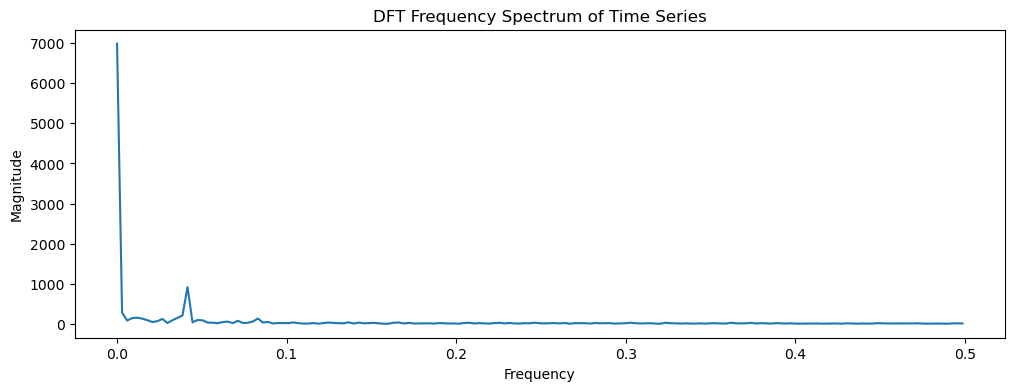

In [136]:
# We are using rfft (real fft) and its associate functions 
# as real world signals usually don't contain complex numbers
from scipy.fft import rfft, rfftfreq, irfft

N = len(ts_data.values)                 # Number of samples in the time series
yf = rfft(ts_data.values)               # Result of the fft
xf = rfftfreq(N)                        # The frequencies which were evaluated

print("The first 5 values of the DFT:")
print(*yf[:5].round(2), sep="\n")

print("\nA snippet of the positive frequencies which were evaluated:")
print(xf[:10])

plt.figure(figsize=(12, 4))
plt.plot(xf, np.abs(yf))

plt.title("DFT Frequency Spectrum of Time Series")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()

The frequency distribution in this example is quite spread out, thus the log scale. Below is another example for a function derived directly from trigonometric functions. This creates a way clearer spectrum:

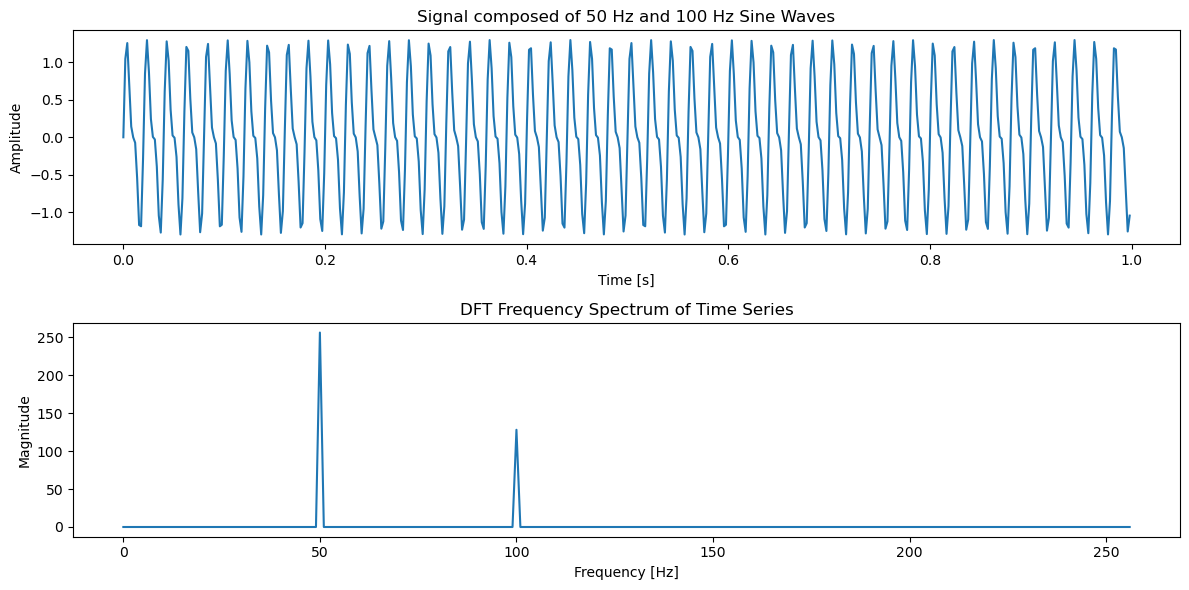

In [137]:
# Play with the time series parameters to see how the DFT changes
n = 512
freq_1 , mag_1 = 50, 1
freq_2 , mag_2 = 100, 0.5

# Data generation
t = np.linspace(0, 1, n, endpoint=False)
wave1 = mag_1 * np.sin(2 * np.pi * freq_1 * t)
wave2 = mag_2 * np.sin(2 * np.pi * freq_2 * t)
signal = wave1 + wave2

# FFT of synthetic signal
signalf = rfft(signal)
xf = rfftfreq(n, d=1.0/n)

# Plotting the synthetic signal and its DFT
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t, signal)
plt.title(f"Signal composed of {freq_1} Hz and {freq_2} Hz Sine Waves")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
plt.plot(xf, np.abs(signalf))
plt.title("DFT Frequency Spectrum of Time Series")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()

From the DFT we can extract the dominant frequencies. In the plot above, the most dominant frequency is at about ~0.85 and the subsequent spikes are approximately multiples of that value.

In [138]:
def reduce_dims_fft(yf, dims):
    # 1: get the contribution of each frequency
    magnitudes = np.abs(yf)

    # 2: Find the indices of the top N dominant frequencies
    freqs_to_keep = dims 
    top_indices = np.argsort(magnitudes)[-freqs_to_keep:]

    # 3: Create a filtered FFT array (zeroing out the rest)
    yf_reduced = np.zeros_like(yf)
    yf_reduced[top_indices] = yf[top_indices]

    return yf_reduced

From these we can simply recreate a signal with the inverse FFT. If frequencies have been removed, the signal often looses some of its complexity. 

The first plot shows the "DC-Term" (coming from AC/DC in electricity, where DFT is often applied). The DC-Term describes the general offset of the data, being a sum of all frequency magnitudes.

The other three show ever more included frequencies in the reduced signal. Thus, they are being closer to the original time series. Keeping all frequencies would result in a perfect inversion.

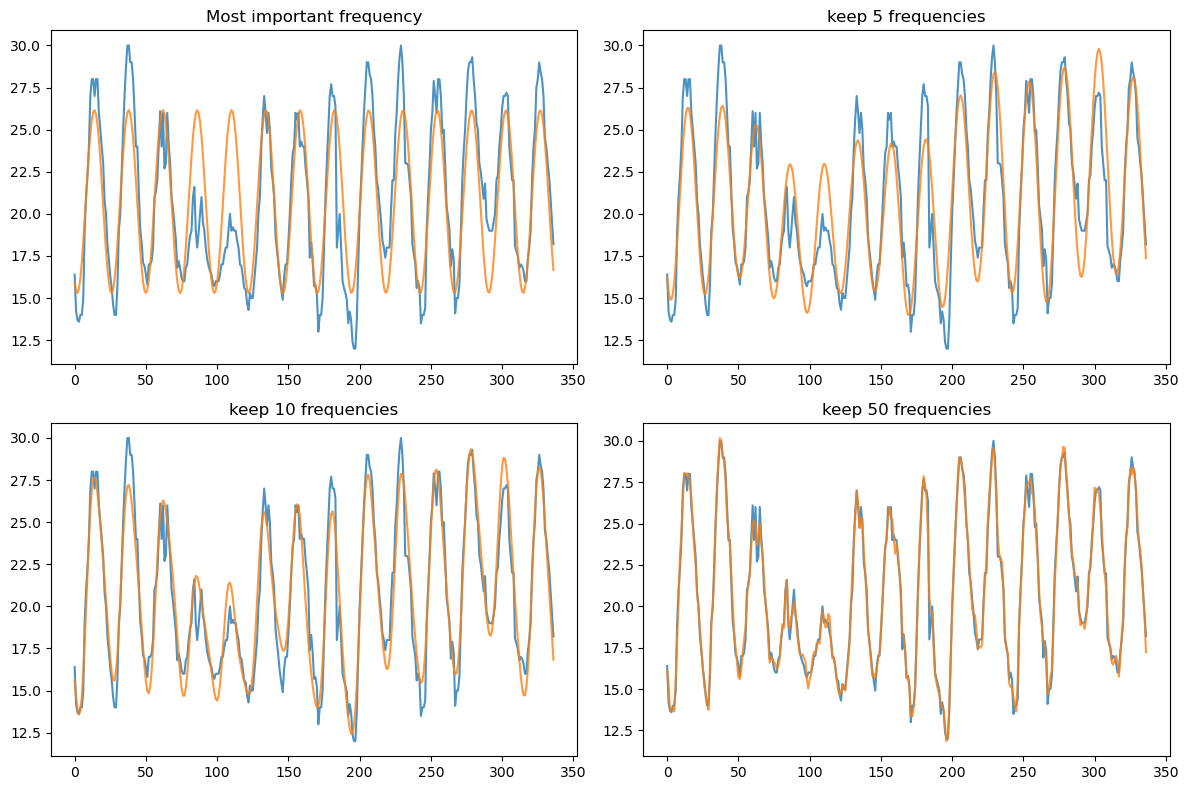

In [153]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(ts_data.values, alpha=0.8)
plt.plot(irfft(reduce_dims_fft(yf, 2), n=N), alpha=0.8)
plt.title("Most important frequency")

plt.subplot(2, 2, 2)
plt.plot(ts_data.values, alpha=0.8)
plt.plot(irfft(reduce_dims_fft(yf, 5), n=N), alpha=0.8)
plt.title("keep 5 frequencies")

plt.subplot(2, 2, 3)
plt.plot(ts_data.values, alpha=0.8)
plt.plot(irfft(reduce_dims_fft(yf, 10), n=N), alpha=0.8)
plt.title("keep 10 frequencies")

plt.subplot(2, 2, 4)
plt.plot(ts_data.values, alpha=0.8)
plt.plot(irfft(reduce_dims_fft(yf, 50), n=N), alpha=0.8)
plt.title("keep 50 frequencies")

plt.tight_layout()
plt.show()

### 2.2. PAA

Piecewise Aggregate Approximation aggregates the values within each tumbling window. 

The window size controls how many data points are averaged at once. PAA algorithms can be implemented either by specifying a window size or the number of PAA segments wanted, as one easily translates to the other.

In [ ]:
# or use pyts.pproximation.PiecewiseAggregateApproximation
def paa(X, n_segments):
    # 1: Split array into number of segments
    segments = np.array_split(X, n_segments)
    segment_lengths = [len(chunk) for chunk in segments] # Store segment lengths for X % n_segments != 0

    # 2: Calculate the mean within each window
    X_paa = np.empty(n_segments)
    for j, segment in enumerate(segments):
        X_paa[j] = np.mean(segment)
        
    return X_paa, segment_lengths

Lets look at some window sizes to see how they affect the PAA function. One can observe the correlation between saved memory and precision loss:

A window size of 2 approximates the time series pretty well, but offers little dimensionality reduction.

A window size of 16, which is around 10% of the number of datapoints in the time series, is unable to capture any valleys. It reduces to a step function.

The correct choice of the window size is memory and data dependent. There are time series which allow such a relatively big window size without loosing important characteristics.

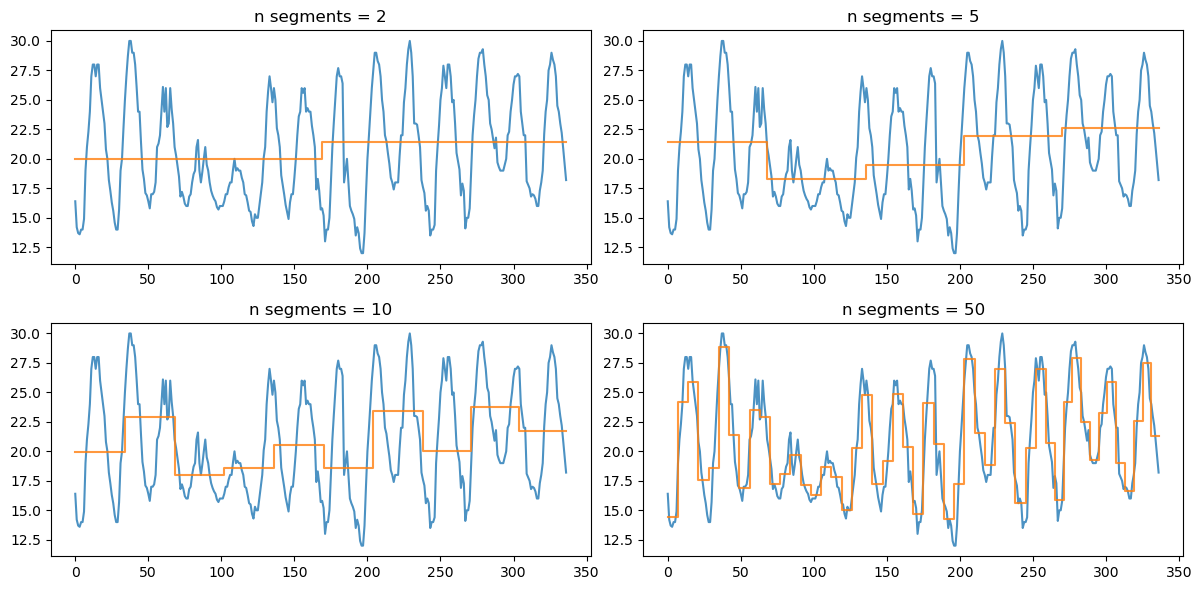

In [173]:
ts_paa_2, paa_len_2 = paa(ts_data, 2)
ts_paa_5, paa_len_5 = paa(ts_data, 5)
ts_paa_10, paa_len_10 = paa(ts_data, 10)
ts_paa_50, paa_len_50 = paa(ts_data, 50)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(ts_data.reset_index(drop=True), alpha=0.8)
plt.plot(np.repeat(ts_paa_2, paa_len_2), alpha=0.8, drawstyle='steps-post')            # we have to repeat each value to get to the original length
plt.title("n segments = 2")

plt.subplot(2, 2, 2)
plt.plot(ts_data.reset_index(drop=True), alpha=0.8)
plt.plot(np.repeat(ts_paa_5, paa_len_5), alpha=0.8, drawstyle='steps-post')            # we have to repeat each value to get to the original length
plt.title("n segments = 5")

plt.subplot(2, 2, 3)
plt.plot(ts_data.reset_index(drop=True), alpha=0.8)
plt.plot(np.repeat(ts_paa_10, paa_len_10), alpha=0.8, drawstyle='steps-post')            # we have to repeat each value to get to the original length
plt.title("n segments = 10")

plt.subplot(2, 2, 4)
plt.plot(ts_data.reset_index(drop=True), alpha=0.8)
plt.plot(np.repeat(ts_paa_50, paa_len_50), alpha=0.8, drawstyle='steps-post')          # we have to repeat each value to get to the original length
plt.title("n segments = 50")

plt.tight_layout()
plt.show()

Comparing PAA to DFT:

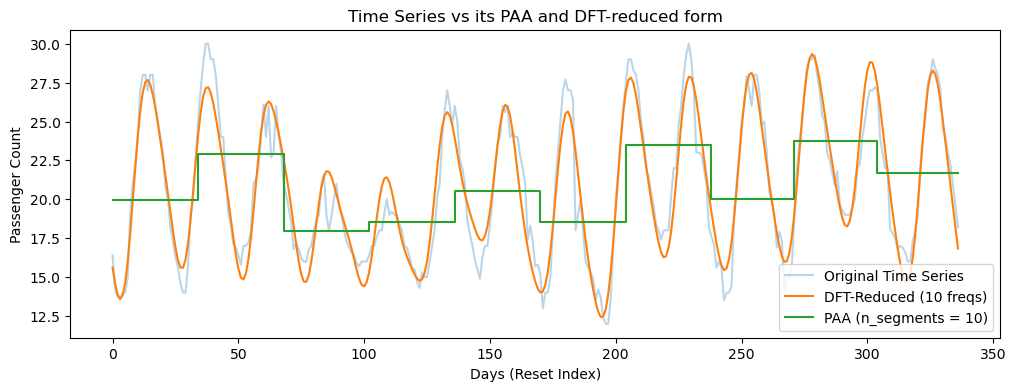

In [174]:
n_dims = 10

plt.figure(figsize=(12, 4))
plt.plot(ts_data.reset_index(drop=True), label="Original Time Series", alpha=0.3)
plt.plot(irfft(reduce_dims_fft(rfft(ts_data.values), n_dims), n=N), label=f"DFT-Reduced ({n_dims} freqs)") # TS -> DFT -> Reduce -> Reverse
ts_paa, paa_lens = paa(ts_data, n_dims)
plt.plot(np.repeat(ts_paa, paa_lens), label=f"PAA (n_segments = {n_dims})", drawstyle='steps-post')

plt.title("Time Series vs its PAA and DFT-reduced form")
plt.xlabel("Days (Reset Index)")
plt.ylabel("Passenger Count")
plt.legend()
plt.show()

### 2.3. SAX

SAX is an evolution of PAA. It takes the averaged PAA segments and maps them to discrete characters (a, b, c...) based on Gaussian probability bins

In [166]:
import string
from scipy.stats import norm

# or use pyts.approximation.SymbolicAggregateApproximation
def sax(X, n_segments, n_bins, return_paa=False):
    # 1: Prepare symbols
    alphabet = list(string.ascii_lowercase)
    bins = np.array(alphabet[:n_bins]) # Converted to numpy array for fast indexing

    # 2: Perform PAA to get averaged results
    X_paa, chunk_lengths = paa(X, n_segments)
    
    # 3: Calculate equiprobable breakpoints using the normal distribution
    breakpoints = norm.ppf(np.linspace(0, 1, n_bins + 1)[1:-1])

    # 4: Convert values into letters
    indices = np.searchsorted(breakpoints, X_paa.copy(), side='left')  # map value to a bin index
    sax_symbols = bins[indices]                                        # use indices to fetch the corresponding letters

    if return_paa:
        return np.array(sax_symbols), X_paa, chunk_lengths # for plotting
    else:
        return np.array(sax_symbols)

Now we are able to create the SAX from the time series. The SAX algorithm assumes a z-normalized input.

If the PAA produces a granular enough reprentation, adjacent peaks and valleys can map to different symbols.

The resulting SAX String:
accaacbaccaabaaaaabcabcbacbaacbbcbabcbaccbbccbabcb


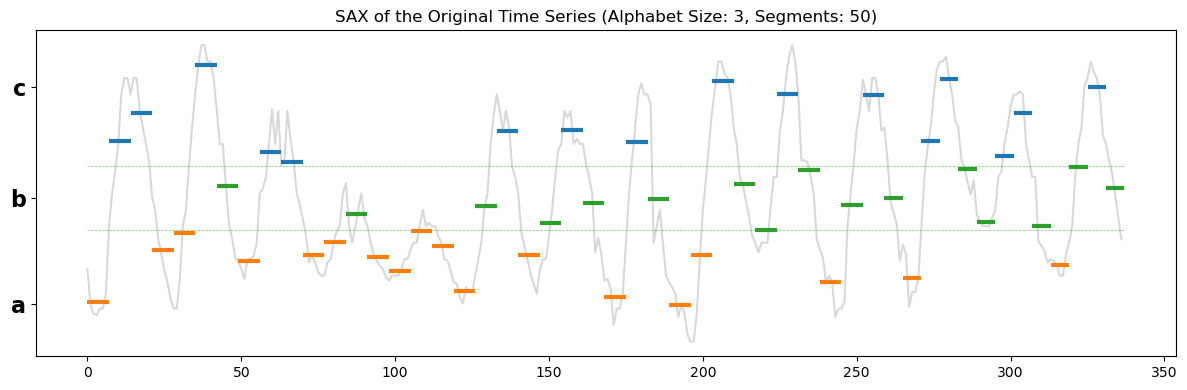

In [168]:
n_bins = 3
n_segments = 50 # Replaced window_size

# Assuming your sax function is now updated to take n_segments
X_sax, X_paa, paa_lens = sax(znorm(ts_data.values), n_segments=n_segments, n_bins=n_bins, return_paa=True)

# print the SAX string
print("The resulting SAX String:")
print("".join(X_sax))

# plot SAX on original time series
plt.figure(figsize=(12, 4))
plt.plot(znorm(ts_data.values), alpha=0.3, color='gray')

# Draw the horizontal bin thresholds
bins = norm.ppf(np.linspace(0, 1, n_bins + 1)[1:-1])
plt.hlines(bins, 0, len(ts_data.values), color='g', linestyles='--', linewidth=0.5, alpha=0.5)

# --- THE FIX: Calculate exact start and end points for variable-length segments ---
x_maxs = np.cumsum(paa_lens)                       # Ends: [len1, len1+len2, len1+len2+len3...]
x_mins = np.concatenate(([0], x_maxs[:-1]))        # Starts: [0, len1, len1+len2...]

cmap = plt.get_cmap('tab10')

# Draw the colored PAA segments
plt.hlines(X_paa, 
           x_mins, 
           x_maxs,
           colors=[cmap(ord(char) % n_bins) for char in X_sax],
           linewidth=3 # Made slightly thicker so the colors pop
           )

# Format the Y-axis to show the SAX letters (a, b, c...) inside the bins
y_min = znorm(ts_data.values).min() - 0.5
y_max = znorm(ts_data.values).max() + 0.5

extended_bounds = np.concatenate(([y_min], bins, [y_max]))
bin_centers = (extended_bounds[:-1] + extended_bounds[1:]) / 2
plt.yticks(ticks=bin_centers, labels=np.unique(list(X_sax)), fontsize=16, fontweight='bold')

plt.title(f"SAX of the Original Time Series (Alphabet Size: {n_bins}, Segments: {n_segments})")
plt.tight_layout()
plt.show()

### 2.4. Additional: Wavelets

Wavelet Transform follows a similar idea to fourier transform: Transforming a time series into a sum of different shapes - those shapes being sinoidal waves for fourier and so called wavelets for wavelet transform. Another similarity is, that there is also a discrete version (DWT) to deal with samples instead of continous signals.

It is based on a mother wavelet and its derived levels. To count as a wavelet, a function has to fullfill some mathematical properties. The easiest (and first found) is the Haar wavelet shown below.

The formula for DWT is $$W(j,k) = \sum_{n=0}^{N-1} x(n) \psi_{j,k}(n)$$ with
- $W(j,k)$ being
- $\sum_{n=0}^{N-1}$ being
- $x(n)$ 
- $\psi_{j,k}(n)$

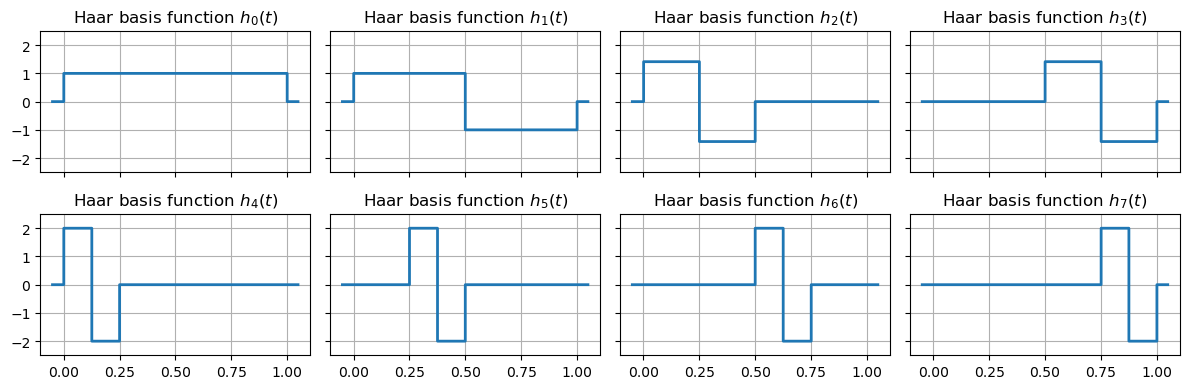

In [145]:
def haar(level, t):
    if level == 0: 
        return np.where((t >= 0) & (t < 1), 1.0, 0.0) # Scaling function
        
    j = int(np.log2(level))        # Scale
    k = level - 2**j               # Shift
    
    # Mother wavelet scaled and shifted
    return (2**(j/2)) * np.where((2**j * t >= k) & (2**j * t < k + 0.5), 1,
                        np.where((2**j * t >= k + 0.5) & (2**j * t < k + 1), -1, 0))

# Time vector
t = np.linspace(-0.05, 1.05, 1000, endpoint=False)

# Plotting in a 2x3 grid
fig, axes = plt.subplots(2, 4, figsize=(12, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes.flat):
    ax.plot(t, haar(i, t), drawstyle='steps-post', lw=2)
    ax.set_title(f'Haar basis function $h_{i}(t)$')
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True)

plt.tight_layout()
plt.show()

Again similar to DFT, computing the original formula for each time point is not feasable. 

Instead, (S.G. Mallat, 1989) showed that one can define a low and high pass filter to slide over the data which creates an equal result but is computed way faster. The filters for Haar wavelets are very simple: taking the average (low-pass filter) and the difference (high-pass filter) between adjacent data points:  

In [146]:
dwt_data = ts_data.copy().to_numpy()[:256]

In [179]:
def dwt_haar(x):    
    # 1. Define the Haar filters
    L = np.array([1, 1]) / np.sqrt(2)   # Low-pass (Scaling filter)
    H = np.array([1, -1]) / np.sqrt(2)  # High-pass (Wavelet filter)
    
    coeffs = []
    approx = x
    
    while len(approx) > 1:
        # 2. Filtering (Cross-Correlation)
        # We slide the L and H filters across every single point in the signal.
        # mode='valid' means the filter only computes where it fully overlaps the data.
        filtered_approx = np.correlate(approx, L, mode='valid')
        filtered_detail = np.correlate(approx, H, mode='valid')
        
        # 3. Decimation (Downsampling by 2)
        # The correlation computed overlapping pairs: (x0, x1), (x1, x2), (x2, x3)...
        # Because Haar is an orthogonal basis, we don't want overlapping windows.
        # We keep only every 2nd value to isolate: (x0, x1), (x2, x3), (x4, x5)...
        next_approx = filtered_approx[::2]
        detail = filtered_detail[::2]
        
        # Store the detail and pass the approximation to the next level
        coeffs.append(detail)
        approx = next_approx
        
    coeffs.append(approx)
    
    return coeffs[::-1]

haar_coeffs = dwt_haar(dwt_data)

print(f"Global Average: {haar_coeffs[0]}")
print(f"Lengths of coefficient list for each level: {[len(level) for level in haar_coeffs]} -> number of coefficients is same as time series length")
print(f"E.g. first few coeffs: {haar_coeffs[1:4]}")

Global Average: [324.1625]
Lengths of coefficient list for each level: [1, 1, 2, 4, 8, 16, 32, 64, 128] -> number of coefficients is same as time series length
E.g. first few coeffs: [array([-10.125]), array([18.58806951, -3.77418244]), array([-11.0125,   8.8   ,   7.35  ,  -6.8625])]


In [148]:
def reduce_dims_dwt(coeffs, k):
    # 1. Flatten all coefficient arrays into one giant 1D array
    all_values = np.concatenate([c.flatten() for c in coeffs])
    
    # 2. Find the threshold magnitude of the k-th largest value
    if k >= len(all_values):
        return coeffs  # Ask to keep more than we have? Change nothing.
    
    threshold = np.sort(np.abs(all_values))[-k]
    
    # 3. Rebuild the list, zeroing out anything below the threshold
    filtered_coeffs = []
    for c in coeffs:
        # np.where(condition, value_if_true, value_if_false)
        thresholded_array = np.where(np.abs(c) >= threshold, c, 0.0)
        filtered_coeffs.append(thresholded_array)
        
    return filtered_coeffs

def inverse_dwt_haar(coeffs):
    approx = coeffs[0]

    for detail in coeffs[1:]:
        # 1. Reverse the math: Rebuild the left and right items
        left_items = (approx + detail) / np.sqrt(2)
        right_items = (approx - detail) / np.sqrt(2)
        
        # 2. Create an empty array twice the size to hold the new sequence
        next_approx = np.empty(len(left_items) + len(right_items), dtype=float)
        
        # 3. Interleave them back together using slicing
        next_approx[0::2] = left_items   # Put left items in even indices (0, 2, 4...)
        next_approx[1::2] = right_items  # Put right items in odd indices (1, 3, 5...)
        
        # Pass the expanded array forward to the next level
        approx = next_approx
        
    return approx

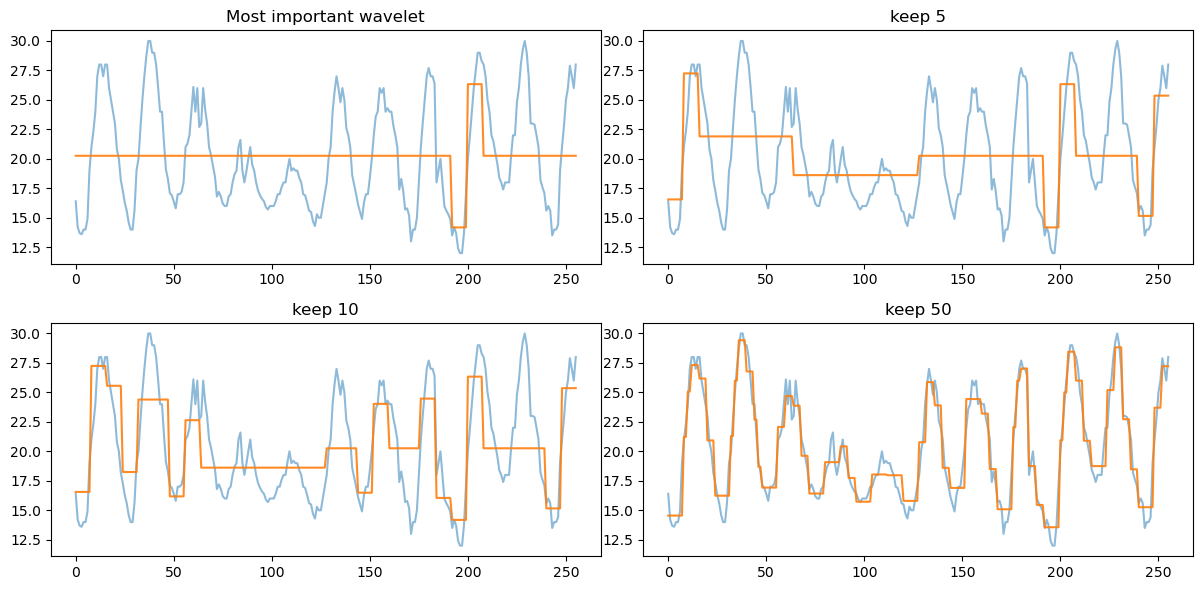

In [170]:
# Plotting dimensionality reduced time series with haar_coeffs from above
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.plot(dwt_data, alpha=0.5)
plt.plot(inverse_dwt_haar(reduce_dims_dwt(haar_coeffs, 2)), alpha=0.9)
plt.title("Most important wavelet")

plt.subplot(2, 2, 2)
plt.plot(dwt_data, alpha=0.5)
plt.plot(inverse_dwt_haar(reduce_dims_dwt(haar_coeffs, 5)), alpha=0.9)
plt.title("keep 5")

plt.subplot(2, 2, 3)
plt.plot(dwt_data, alpha=0.5)
plt.plot(inverse_dwt_haar(reduce_dims_dwt(haar_coeffs, 10)), alpha=0.9)
plt.title("keep 10")

plt.subplot(2, 2, 4)
plt.plot(dwt_data, alpha=0.5)
plt.plot(inverse_dwt_haar(reduce_dims_dwt(haar_coeffs, 50)), alpha=0.9)
plt.title("keep 50")

plt.tight_layout()
plt.show()

One can observe how the most important feature of wavelets is used: The utilization of the time domain instead of just the frequency domain (as in Fourier Transform).

## 3. Exercises

Implement Piecewise Linear Approximation PLA or Adaptive Piecewise Constant Approximation (APCA)

In [150]:
def pla(time_series):
    pass

def apca(time_series):
    pass

Detrend a time series

Another Wavelet